<a href="https://colab.research.google.com/github/Mukhesh27/Hybrid_CNN_Transformer_model_for_ecg/blob/main/Model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision scikit-learn matplotlib
!pip install torchinfo
import os
import torch
import torch.nn as nn
import numpy as np
import random
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from IPython.display import Javascript

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
DATA_DIR = "/content/drive/MyDrive/ecg2/ecg_img/"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['F', 'N', 'Q', 'S', 'V']


In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=512, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=2, stride=2)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class HybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])

        self.patch_embed = PatchEmbedding(512, 256)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = self.patch_embed(x)
        x = self.transformer(x)

        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)

        return self.fc(x)

In [ ]:
model = HybridModel(5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
HybridModel                                   [1, 5]                    --
├─Sequential: 1-1                             [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           73,984
│    └─Sequential: 2-6                        [1, 128, 28, 28]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 28, 28]          230,144
│    │    └─BasicBlock: 3-4                   [1, 128, 28, 28]          295,42

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(model, loader, threshold=0.7, print_results=True):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            conf, preds = torch.max(probs, dim=1)
            mask = conf >= threshold

            y_true.extend(labels[mask].cpu().numpy())
            y_pred.extend(preds[mask].cpu().numpy())

    if len(y_true) == 0:
        print("No predictions passed threshold!")
        return 0, [], []

    acc = accuracy_score(y_true, y_pred)

    if print_results:
        print("\n===== FINAL RESULTS =====")
        print(f"Accuracy: {acc*100:.2f}%")
        print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))
        print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

    return acc, y_true, y_pred

In [ ]:
train_losses = []
val_accuracies = []

EPOCHS = 10

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    acc = evaluate(model, test_loader)

    train_losses.append(loss)
    val_accuracies.append(acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc*100:.2f}%")

    # 🔥 Save every epoch (IMPORTANT)
    torch.save(model.state_dict(), f"/content/drive/MyDrive/ecg_epoch_{epoch+1}.pth")


===== RESULTS =====
Accuracy: 90.66%

Classification Report:
               precision    recall  f1-score   support

           0     0.3463    0.8056    0.4843       144
           1     0.9773    0.6903    0.8091      1311
           2     0.9645    0.9981    0.9810      1604
           3     1.0000    1.0000    1.0000       539
           4     0.8909    0.9792    0.9330      1393

    accuracy                         0.9066      4991
   macro avg     0.8358    0.8946    0.8415      4991
weighted avg     0.9333    0.9066    0.9102      4991


Confusion Matrix:
 [[ 116    4    0    0   24]
 [ 207  905   58    0  141]
 [   1    0 1601    0    2]
 [   0    0    0  539    0]
 [  11   17    1    0 1364]]

Epoch 1/10
Loss: 0.0632
Accuracy: 90.66%

===== RESULTS =====
Accuracy: 90.97%

Classification Report:
               precision    recall  f1-score   support

           0     0.3629    0.8854    0.5148       157
           1     0.9710    0.7196    0.8266      1398
           2     0.

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/ecg_final_pap.pth")
print("Final model saved!")

Final model saved!


In [ ]:
import json

with open("/content/drive/MyDrive/training_log.json", "w") as f:
    json.dump({
        "loss": train_losses,
        "accuracy": val_accuracies
    }, f)

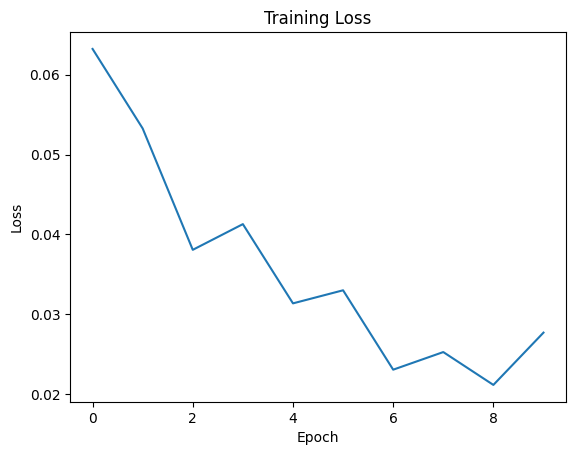

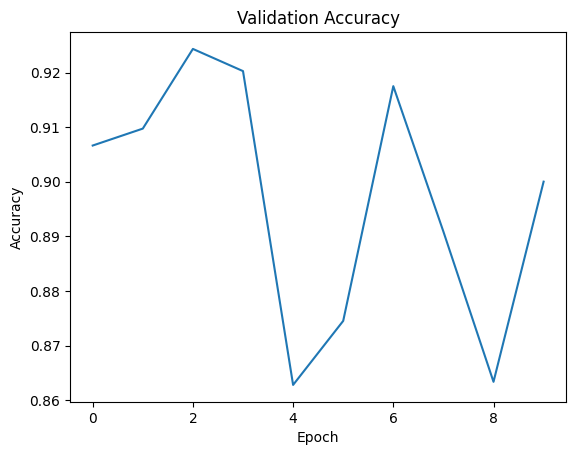

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
model = HybridModel(5).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/ecg_final_pap.pth"))
model.eval()

print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded successfully!


In [ ]:
final_acc, y_true, y_pred = evaluate(model, test_loader, threshold=0.7, print_results=True)


===== FINAL RESULTS =====
Accuracy: 90.00%

Classification Report:
               precision    recall  f1-score   support

           0     0.4781    0.8675    0.6165       151
           1     0.9956    0.6009    0.7495      1135
           2     0.9846    0.9969    0.9907      1605
           3     1.0000    0.9944    0.9972       539
           4     0.8191    0.9965    0.8991      1431

    accuracy                         0.9000      4861
   macro avg     0.8555    0.8913    0.8506      4861
weighted avg     0.9244    0.9000    0.8965      4861


Confusion Matrix:
 [[ 131    2    0    0   18]
 [ 141  682   20    0  292]
 [   0    0 1600    0    5]
 [   0    0    3  536    0]
 [   2    1    2    0 1426]]


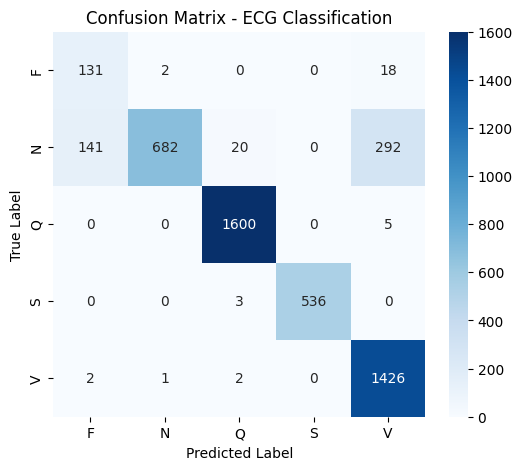

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Class names (important for your paper)
class_names = ['F', 'N', 'Q', 'S', 'V']

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ECG Classification")

# Save image (VERY IMPORTANT for paper)
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()